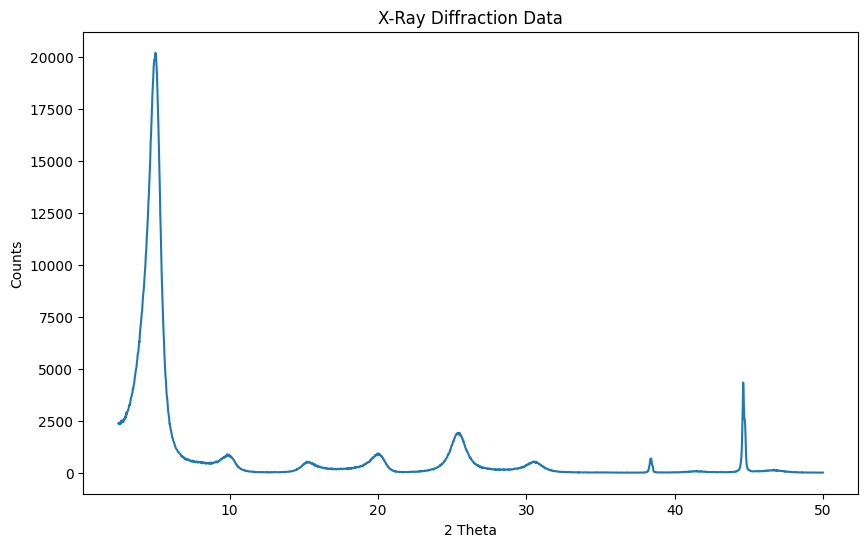

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/Users/carolinecarr/64labs/xraydiff.csv')

x_data = df.iloc[:, 0].to_numpy()
y_data = df.iloc[:, 1].to_numpy()

mask = ~np.isnan(x_data) & ~np.isnan(y_data)
x_data = x_data[mask]
y_data = y_data[mask]

plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data)

plt.ylabel(df.columns[1])
plt.xlabel(df.columns[0]) 
plt.title('X-Ray Diffraction Data')

plt.show()


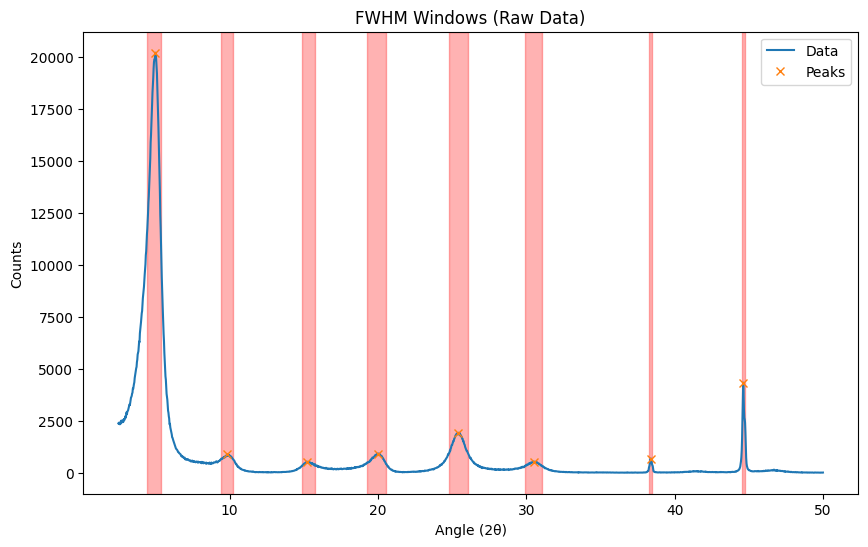

In [53]:
from scipy.signal import find_peaks, peak_widths
import numpy as np
import matplotlib.pyplot as plt

peaks, properties = find_peaks(
    y_data,
    height=500,
    distance=60,
    prominence=50
)

results = peak_widths(y_data, peaks, rel_height=0.5)

widths = results[0]
left_ips = results[2]
right_ips = results[3]

windows = []

for i in range(len(peaks)):

    x_left = np.interp(left_ips[i], np.arange(len(x_data)), x_data)
    x_right = np.interp(right_ips[i], np.arange(len(x_data)), x_data)
    
    windows.append((x_left, x_right))

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, label="Data")

for (x_left, x_right) in windows:
    plt.axvspan(x_left, x_right, color='red', alpha=0.3)

plt.plot(x_data[peaks], y_data[peaks], "x", label="Peaks")

plt.title("FWHM Windows (Raw Data)")
plt.xlabel("Angle (2θ)")
plt.ylabel("Counts")
plt.legend()
plt.show()


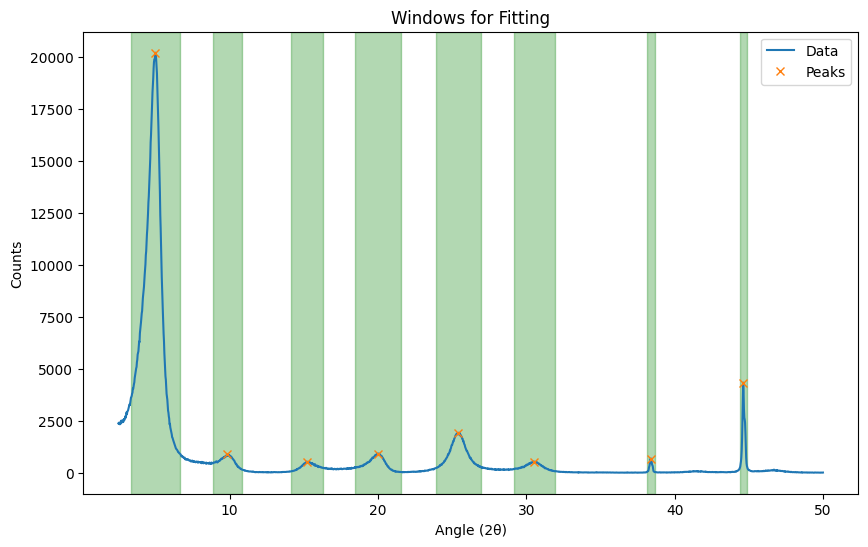

In [54]:
from scipy.optimize import curve_fit
adaptive_windows = []

# Parameters
max_factor_default = 2.5
max_factor_first_peak = 3.5  

for i, peak_idx in enumerate(peaks):
    

    x_left_fwhm = np.interp(left_ips[i], np.arange(len(x_data)), x_data)
    x_right_fwhm = np.interp(right_ips[i], np.arange(len(x_data)), x_data)
    
    fwhm = x_right_fwhm - x_left_fwhm
    
    center = x_data[peak_idx]
    

    max_factor = max_factor_first_peak if i == 0 else max_factor_default
    
    width = max_factor * fwhm
    
    x_left = center - width / 2
    x_right = center + width / 2
    
    adaptive_windows.append((x_left, x_right))

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, label="Data")

for (x_left, x_right) in adaptive_windows:
    plt.axvspan(x_left, x_right, color='green', alpha=0.3)

plt.plot(x_data[peaks], y_data[peaks], "x", label="Peaks")

plt.title("Windows for Fitting")
plt.xlabel("Angle (2θ)")
plt.ylabel("Counts")
plt.legend()
plt.show()



In [55]:
from scipy.optimize import curve_fit
import numpy as np

def gaussian_linear(x, A, mu, sigma, m, b):
    """
    A: peak height (amplitude)
    mu: peak position (2θ)
    sigma: standard deviation
    m, b: linear background
    """
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + m * x + b


In [56]:
results = []
cov_matrices = []  

for i, (x_left, x_right) in enumerate(adaptive_windows):
    
    mask = (x_data >= x_left) & (x_data <= x_right)
    x_fit = x_data[mask]
    y_fit = y_data[mask]  

    if len(x_fit) < 5:
        print(f"Skipping peak {i}, window too small")
        continue

    sigma_y = np.sqrt(np.maximum(y_fit, 1))

    
    dx = np.mean(np.diff(x_fit))
    
    N0 = np.sum(y_fit) * dx
    
    mu0 = x_data[peaks[i]]
    
    x_left_fwhm = np.interp(left_ips[i], np.arange(len(x_data)), x_data)
    x_right_fwhm = np.interp(right_ips[i], np.arange(len(x_data)), x_data)
    sigma0 = (x_right_fwhm - x_left_fwhm) / 2.355

    m0 = 0
    b0 = np.min(y_fit)

    p0 = [N0, mu0, sigma0, m0, b0]

    try:
        popt, pcov = curve_fit(
            gaussian_linear,
            x_fit,
            y_fit,
            p0=p0,
            sigma=sigma_y,
            absolute_sigma=True,
            maxfev=20000
        )

        perr = np.sqrt(np.diag(pcov))

        results.append({
            "Peak": i,
            "mu": popt[1],
            "mu_err": perr[1],
            "sigma": popt[2],
            "sigma_err": perr[2],
            "N": popt[0],
            "N_err": perr[0],
            "m": popt[3],
            "b": popt[4]
        })

        cov_matrices.append(pcov)

    except RuntimeError:
        print(f"Fit failed for peak {i}")
        results.append({
            "Peak": i,
            "mu": np.nan,
            "mu_err": np.nan,
            "sigma": np.nan,
            "sigma_err": np.nan,
            "N": np.nan,
            "N_err": np.nan,
            "m": np.nan,
            "b": np.nan
        })
        cov_matrices.append(None)

df_results = pd.DataFrame(results)

df_results


,Peak,mu,mu_err,sigma,sigma_err,N,N_err,m,b
0,0,4.900138,0.000739,0.430718,0.000752,16093.328897,28.222965,-1182.622361,8700.017582
1,1,9.923618,0.006741,0.397930,0.009754,558.837636,9.109439,-193.628025,2211.324182
2,2,15.277758,0.007709,0.402263,0.009951,348.481917,6.063623,82.296753,-1093.136206
3,3,19.972169,0.003919,0.449792,0.004137,729.959690,6.071355,-90.233366,1971.989385
4,4,25.415577,0.002815,0.502808,0.003270,1581.530799,8.291569,17.090187,-158.938059
5,5,30.548554,0.007233,0.495988,0.009244,379.879970,4.941408,-40.325379,1370.671316
6,6,38.403437,0.001654,0.083972,0.001828,623.768561,11.654997,-29.713343,1186.252737
7,7,44.655814,0.000837,0.085008,0.000986,3472.876010,29.330727,161.976430,-6991.196895


,Peak,mu,two_theta_total_err,d_spacing,d_spacing_err
0,0,4.900138,0.007255,1.801924,0.002666
1,1,9.923618,0.009875,0.890606,0.000884
2,2,15.277758,0.010560,0.579482,0.000398
3,3,19.972169,0.008212,0.444210,0.000181
4,4,25.415577,0.007747,0.350170,0.000105
5,5,30.548554,0.010218,0.292401,0.000095
6,6,38.403437,0.007404,0.234209,0.000043
7,7,44.655814,0.007265,0.202760,0.000031


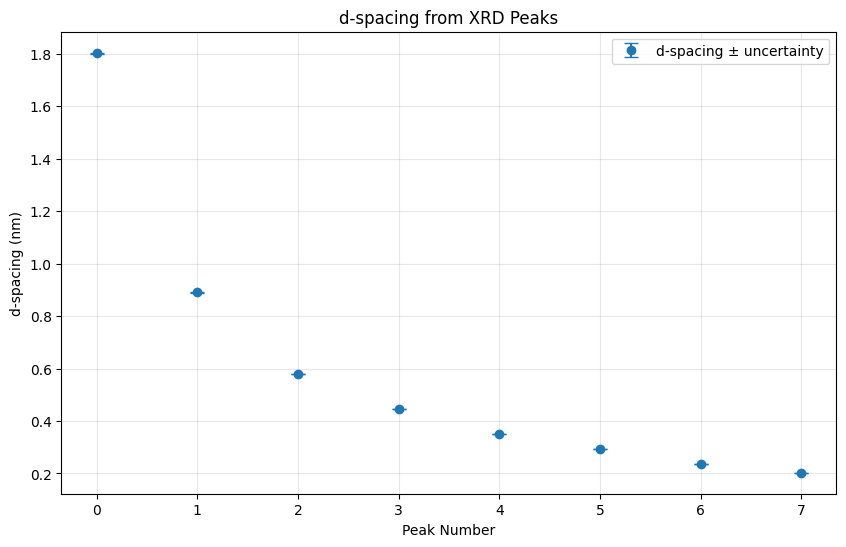

In [57]:
import numpy as np
import matplotlib.pyplot as plt


step_size = np.mean(np.diff(x_data))
sigma_step = step_size / np.sqrt(12)


df_results['two_theta_total_err'] = np.sqrt(
    df_results['mu_err']**2 + sigma_step**2
)


wavelength = 0.15406 

theta_rad = np.deg2rad(df_results['mu'] / 2)
theta_err_rad = np.deg2rad(df_results['two_theta_total_err'] / 2)

df_results['d_spacing'] = wavelength / (2 * np.sin(theta_rad))


df_results['d_spacing_err'] = np.abs(
    (wavelength * np.cos(theta_rad)) / (2 * np.sin(theta_rad)**2)
) * theta_err_rad


display(df_results[['Peak', 'mu', 'two_theta_total_err', 'd_spacing', 'd_spacing_err']])


plt.figure(figsize=(10,6))
plt.errorbar(
    df_results['Peak'],
    df_results['d_spacing'],
    yerr=df_results['d_spacing_err'],
    fmt='o',
    capsize=5,
    label="d-spacing ± uncertainty"
)

plt.xlabel("Peak Number")
plt.ylabel("d-spacing (nm)")
plt.title("d-spacing from XRD Peaks")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


d1 = 1.8563 ± 0.0337 nm


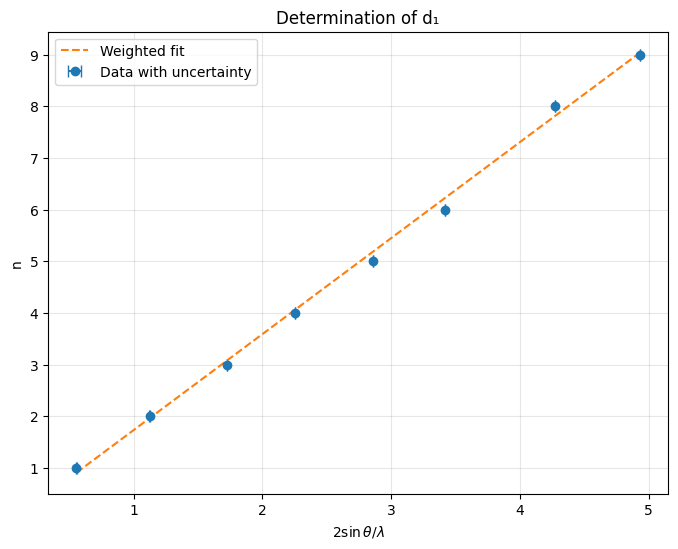

   Peak  d_spacing  n
0     0   1.801924  1
1     1   0.890606  2
2     2   0.579482  3
3     3   0.444210  4
4     4   0.350170  5
5     5   0.292401  6
6     6   0.234209  8
7     7   0.202760  9


In [58]:
import numpy as np
import matplotlib.pyplot as plt


wavelength = 0.15406  # nm


theta_rad = np.deg2rad(df_results['mu'] / 2)
theta_err_rad = np.deg2rad(df_results['two_theta_total_err'] / 2)

df_results['x_val'] = 2 * np.sin(theta_rad) / wavelength

df_results['x_err'] = (2 * np.cos(theta_rad) / wavelength) * theta_err_rad

d1_est = df_results['d_spacing'].iloc[0]
df_results['n'] = np.round(d1_est / df_results['d_spacing']).astype(int)

weights = 1 / df_results['x_err']**2

coeffs, cov = np.polyfit(
    df_results['x_val'],
    df_results['n'],
    1,
    w=weights,
    cov=True
)

slope = coeffs[0]
intercept = coeffs[1]
slope_err = np.sqrt(cov[0, 0])


d1 = slope
d1_err = slope_err

print(f"d1 = {d1:.4f} ± {d1_err:.4f} nm")


plt.figure(figsize=(8,6))

plt.errorbar(
    df_results['x_val'],
    df_results['n'],
    xerr=df_results['x_err'],
    fmt='o',
    capsize=4,
    label="Data with uncertainty"
)

# Fit line
x_fit = np.linspace(min(df_results['x_val']), max(df_results['x_val']), 100)
plt.plot(x_fit, slope * x_fit + intercept, linestyle='--', label="Weighted fit")

plt.xlabel(r"$2 \sin\theta / \lambda$")
plt.ylabel("n")
plt.title("Determination of d₁")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


print(df_results[['Peak','d_spacing','n']])

d1 = 1.7442 ± 0.0109 nm


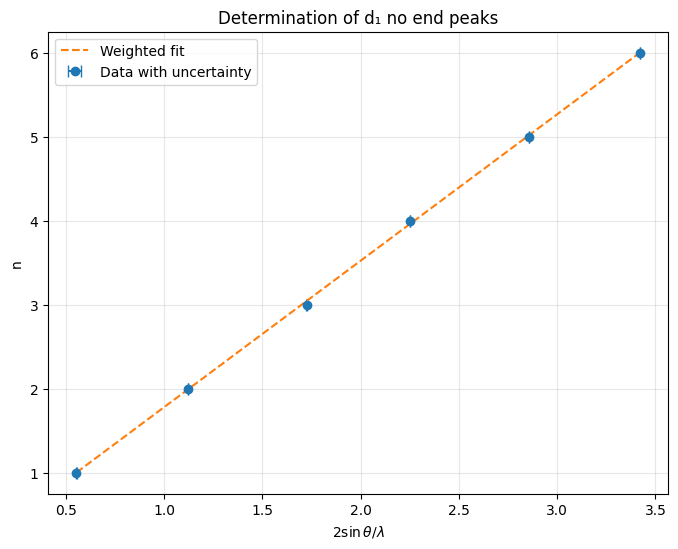

,Peak,d_spacing,n,x_val,x_err
0,0,1.801924,1,0.554962,0.000821
1,1,0.890606,2,1.122831,0.001115
2,2,0.579482,3,1.725678,0.001186
3,3,0.444210,4,2.251188,0.000916
4,4,0.350170,5,2.855755,0.000856
5,5,0.292401,6,3.419966,0.001117


In [59]:
import numpy as np
import matplotlib.pyplot as plt


df_results2 = df_results.iloc[:-2].copy()


theta_rad = np.deg2rad(df_results2['mu'] / 2)
theta_err_rad = np.deg2rad(df_results2['two_theta_total_err'] / 2)

df_results2['x_val'] = 2 * np.sin(theta_rad) / wavelength


df_results2['x_err'] = (2 * np.cos(theta_rad) / wavelength) * theta_err_rad

d1_est = df_results2['d_spacing'].iloc[0]
df_results2['n'] = np.round(d1_est / df_results2['d_spacing']).astype(int)


weights = 1 / df_results2['x_err']**2

coeffs, cov = np.polyfit(
    df_results2['x_val'],
    df_results2['n'],
    1,
    w=weights,
    cov=True
)

slope = coeffs[0]
intercept = coeffs[1]
slope_err = np.sqrt(cov[0, 0])


d1 = slope
d1_err = slope_err

print(f"d1 = {d1:.4f} ± {d1_err:.4f} nm")


plt.figure(figsize=(8,6))

plt.errorbar(
    df_results2['x_val'],
    df_results2['n'],
    xerr=df_results2['x_err'],
    fmt='o',
    capsize=4,
    label="Data with uncertainty"
)

# Fit line
x_fit = np.linspace(min(df_results2['x_val']), max(df_results2['x_val']), 100)
plt.plot(x_fit, slope * x_fit + intercept, linestyle='--', label="Weighted fit")

plt.xlabel(r"$2 \sin\theta / \lambda$")
plt.ylabel("n")
plt.title("Determination of d₁ no end peaks")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


display(df_results2[['Peak', 'd_spacing', 'n', 'x_val', 'x_err']])


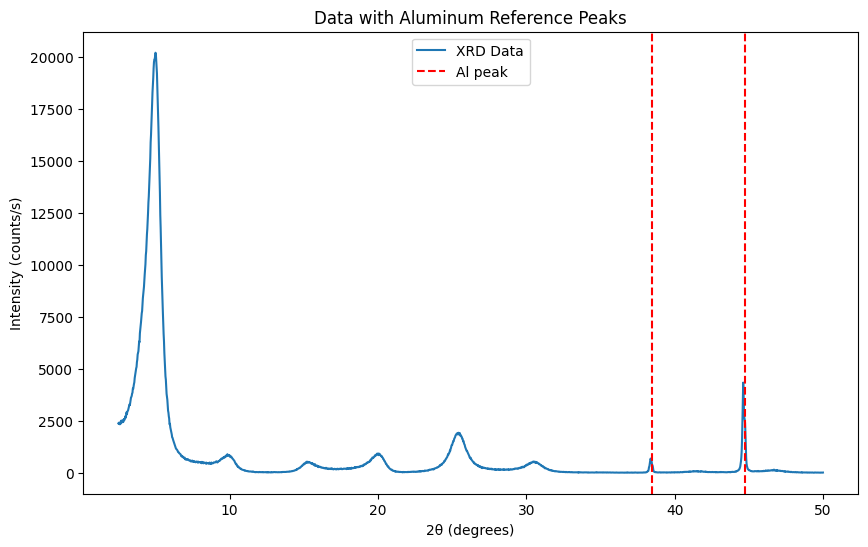

In [61]:

al_2theta = [38.47, 44.74] 
plt.figure(figsize=(10,6))
plt.plot(x_data, y_data, label='XRD Data')
for angle in al_2theta:
    plt.axvline(angle, color='red', linestyle='--', label='Al peak' if angle==al_2theta[0] else "")
plt.xlabel('2θ (degrees)')
plt.ylabel('Intensity (counts/s)')
plt.title('Data with Aluminum Reference Peaks')
plt.legend()
plt.show()